# Week 1 Group Projects

This notebook is a template workspace for the week 1 group projects involving
the [Reproducible Brain Charts](https://reprobrainchart.github.io/) (RBC)
database. Herein, we demonstrate how to access the RBC data and demonstrate a
linear regression analysis on the dataset.

## Getting Started with RBC Data

To load in some of the RBC data, we'll use some tools already installed on the
HUB: `rbclib` and `pandas`.
The `rbclib` library allows us to access RBC data from the cloud; it is
demonstrated below.

The `pandas` library handles spreadsheet data (called `DataFrame`s in Python)
and can read tab-separated and comma-separated value files (`*.tsv` and
`*.csv` files).

In [1]:
# We will need the RBCPath type from the rbclib package to load data from the RBC.
from rbclib import RBCPath

# We'll also want to load some data directly from the filesystem.
from pathlib import Path

# We'll want to load/process some of the data using pandas and numpy.
import pandas as pd
import numpy as np

/srv/conda/envs/notebook/lib/python3.10/site-packages/google/api_core/_python_version_support.py:255: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


### Accessing the PNC Dataset

The RBC project contains many datasets; for this project, we will focus on
just one of these datasets: the
[Philadelphia Neurodevelopmental Cohort](
https://www.med.upenn.edu/bbl/philadelphianeurodevelopmentalcohort.html)
(PNC). The PNC contains a lot of data, including raw MRI data. However, due to
the time constraints for this project, we suggest that teams focus on the
already processed data provided by the RBC, which is described below.

The RBC's data is stored in a combination of GitHub repositories and Amazon S3
buckets. The RBC GitHub repositories all belong to the organization
[`ReproBrainChart`](https://github.com/ReproBrainChart), and each contains a
subset of the data for one of the RBC datasets; for the PNC dataset, all
repositories names start with `PNC_`:

* `PNC_FreeSurfer`: structural data processed by FreeSurfer.
* `PNC_BIDS`: raw MRI scan data in the
  [Brain Imaging Data Structure](https://bids.neuroimaging.io/index.html)
  format.
* `PNC_CPAC`: processed functional MRI data.

One typically accesses the RBC using the [`datalad`](https://www.datalad.org/)
tool (see the [RBC page on accessing the data](
https://reprobrainchart.github.io/docs/get_data) for more information).
However, we will access the data using the `RBCPath` type that was imported in
the code-cell above (`from rbclib import RBCPath`). This type inherits from a
type called `CloudPath` (from the library [`cloudpathlib`](
https://cloudpathlib.drivendata.org/stable/)); it represents the path of a
file in the RBC dataset and can be used to access data in thecloud as if it
were local.

For example, the following cell creates an `RBCPath` to a subject's FreeSurfer
data directory then lists and prints the contents.

In [2]:
# This path refers to the repo github.com:ReproBrainChart/PNC_FreeSurfer;
# Subject 1000393599's directory is used as an example.
subject_id = 1000393599
# To browse the repo, use this link:
# https://github.com/ReproBrainChart/PNC_FreeSurfer/tree/main
sub_path = RBCPath(f'rbc://PNC_FreeSurfer/freesurfer/sub-{subject_id}')

# This path refers to a directory:
assert sub_path.is_dir()

# Print each file in the directory:
for file in sub_path.iterdir():
    print(repr(file))

RBCPath('rbc://PNC_FreeSurfer//home/jovyan/shared/data/RBC/repos/PNC_FreeSurfer/freesurfer/sub-1000393599/sub-1000393599_brainmeasures.json')
RBCPath('rbc://PNC_FreeSurfer//home/jovyan/shared/data/RBC/repos/PNC_FreeSurfer/freesurfer/sub-1000393599/sub-1000393599_brainmeasures.tsv')
RBCPath('rbc://PNC_FreeSurfer//home/jovyan/shared/data/RBC/repos/PNC_FreeSurfer/freesurfer/sub-1000393599/sub-1000393599_freesurfer.tar.xz')
RBCPath('rbc://PNC_FreeSurfer//home/jovyan/shared/data/RBC/repos/PNC_FreeSurfer/freesurfer/sub-1000393599/sub-1000393599_fsLR_den-164k.tar.xz')
RBCPath('rbc://PNC_FreeSurfer//home/jovyan/shared/data/RBC/repos/PNC_FreeSurfer/freesurfer/sub-1000393599/sub-1000393599_fsaverage.tar.xz')
RBCPath('rbc://PNC_FreeSurfer//home/jovyan/shared/data/RBC/repos/PNC_FreeSurfer/freesurfer/sub-1000393599/sub-1000393599_regionsurfacestats.tsv')


If we want to open and load one of these files, we can do so using the
`RBCPath.open` method. This method is like the `Path.open` method (from the
built-in Python library [`pathlib`](1)). For example, if we want to load this
subject's `regionsurfacestats.tsv` file, we can do so as follows.

[1]: https://docs.python.org/3/library/pathlib.html

In [3]:
# We can construct new paths by using the `/` operator. This is identical to
# how paths are constructed in the `pathlib` module.
stats_filepath = sub_path / f'sub-{subject_id}_regionsurfacestats.tsv'

# Use pandas to read in the TSV file then display it:

print(f"Loading {stats_filepath} ...")
with stats_filepath.open('r') as f:
    data = pd.read_csv(f, sep='\t')

data.head(10)

Loading rbc://PNC_FreeSurfer/freesurfer/sub-1000393599/sub-1000393599_regionsurfacestats.tsv ...


,subject_id,session_id,atlas,hemisphere,StructName,NumVert,SurfArea,GrayVol,ThickAvg,ThickStd,...,StdDev_wgpct,Min_wgpct,Max_wgpct,Range_wgpct,SNR_wgpct,Mean_piallgi,StdDev_piallgi,Min_piallgi,Max_piallgi,Range_piallgi
0,sub-1000393599,NaN,aparc.DKTatlas,lh,caudalanteriorcingulate,1668,1121,3493,2.870,0.588,...,5.8371,-1.8413,42.8855,44.7269,4.4281,1.9877,0.0777,1.8054,2.1455,0.3402
1,sub-1000393599,NaN,aparc.DKTatlas,lh,caudalmiddlefrontal,3308,2236,7030,2.882,0.537,...,4.6666,7.1531,40.4774,33.3243,5.0341,3.3898,0.2448,2.7003,3.8032,1.1029
2,sub-1000393599,NaN,aparc.DKTatlas,lh,cuneus,4102,2619,5753,2.019,0.490,...,5.2623,-13.1617,33.8137,46.9754,3.0343,3.2453,0.3093,2.4099,3.5491,1.1392
3,sub-1000393599,NaN,aparc.DKTatlas,lh,entorhinal,737,549,2714,3.655,0.585,...,6.0438,2.5989,37.5099,34.9110,3.4560,2.6710,0.1285,2.4654,2.9647,0.4993
4,sub-1000393599,NaN,aparc.DKTatlas,lh,fusiform,4115,2822,8180,2.738,0.526,...,5.2854,-5.9378,39.6908,45.6286,3.9405,2.8272,0.1093,2.3304,3.1105,0.7800
5,sub-1000393599,NaN,aparc.DKTatlas,lh,inferiorparietal,7381,4819,13525,2.573,0.484,...,5.6378,-3.7520,38.6876,42.4396,3.7227,3.3609,0.1179,2.9774,3.6869,0.7095
6,sub-1000393599,NaN,aparc.DKTatlas,lh,inferiortemporal,4828,3339,11870,2.869,0.699,...,7.6604,-20.1757,61.3693,81.5450,2.8903,2.8822,0.2684,2.3255,3.5120,1.1865
7,sub-1000393599,NaN,aparc.DKTatlas,lh,isthmuscingulate,1578,1002,2545,2.371,0.719,...,5.6952,-1.1202,35.8699,36.9901,3.6037,2.7171,0.2753,2.1326,3.2785,1.1458
8,sub-1000393599,NaN,aparc.DKTatlas,lh,lateraloccipital,10035,6271,14082,2.090,0.618,...,5.9177,-9.0185,48.8780,57.8965,2.9599,2.8599,0.2889,2.3391,3.6048,1.2657
9,sub-1000393599,NaN,aparc.DKTatlas,lh,lateralorbitofrontal,4309,2920,9159,2.729,0.807,...,9.4583,-25.3220,96.6036,121.9256,2.3332,2.5744,0.4912,2.0182,4.3551,2.3370


In [4]:
data.columns

Index(['subject_id', 'session_id', 'atlas', 'hemisphere', 'StructName',
       'NumVert', 'SurfArea', 'GrayVol', 'ThickAvg', 'ThickStd', 'MeanCurv',
       'GausCurv', 'FoldInd', 'CurvInd', 'Index', 'SegId', 'Mean_wgpct',
       'StdDev_wgpct', 'Min_wgpct', 'Max_wgpct', 'Range_wgpct', 'SNR_wgpct',
       'Mean_piallgi', 'StdDev_piallgi', 'Min_piallgi', 'Max_piallgi',
       'Range_piallgi'],
      dtype='object')

In [5]:
data['atlas'].unique()

array(['aparc.DKTatlas', 'aparc.a2009s', 'aparc', 'BA_exvivo', 'AAL',
       'CC200', 'CC400', 'glasser', 'gordon333dil', 'HOCPATh25',
       'Juelich', 'PALS_B12_Brodmann',
       'Schaefer2018_1000Parcels_17Networks_order',
       'Schaefer2018_1000Parcels_7Networks_order',
       'Schaefer2018_100Parcels_17Networks_order',
       'Schaefer2018_100Parcels_7Networks_order',
       'Schaefer2018_200Parcels_17Networks_order',
       'Schaefer2018_200Parcels_7Networks_order',
       'Schaefer2018_300Parcels_17Networks_order',
       'Schaefer2018_300Parcels_7Networks_order',
       'Schaefer2018_400Parcels_17Networks_order',
       'Schaefer2018_400Parcels_7Networks_order',
       'Schaefer2018_500Parcels_17Networks_order',
       'Schaefer2018_500Parcels_7Networks_order',
       'Schaefer2018_600Parcels_17Networks_order',
       'Schaefer2018_600Parcels_7Networks_order',
       'Schaefer2018_700Parcels_17Networks_order',
       'Schaefer2018_700Parcels_7Networks_order',
       'Schaefer

### Getting the Participant Lists and Metadata

We have pre-sorted the participants in the PNC study into a training and a
test dataset. Basic metadata about each participant can be found in TSV files
in the `shared` directory in your home directory.

In [6]:
# Participant meta-data is generally located in the BIDS repository for each
# study:
rbcdata_path = Path('/home/jovyan/shared/data/RBC')
train_filepath = rbcdata_path / 'train_participants.tsv'
test_filepath = rbcdata_path / 'test_participants.tsv'

# Load the PNC participants TSV files...
with train_filepath.open('r') as f:
    train_data = pd.read_csv(f, sep='\t')
with test_filepath.open('r') as f:
    test_data = pd.read_csv(f, sep='\t')

# We can also concatenate the two datasets into a single dataset of all
# study participants:
all_data = pd.concat([train_data, test_data])

# Display the full dataframe:
all_data.head(10)
len(all_data.columns)

15

In [7]:
all_data.columns

Index(['participant_id', 'study', 'study_site', 'session_id', 'wave', 'age',
       'sex', 'race', 'ethnicity', 'bmi', 'handedness',
       'participant_education', 'parent_1_education', 'parent_2_education',
       'p_factor'],
      dtype='object')

## Project Goal: Predict the `p_factor`

The RBC datasets include a variable for each subject called the `p_factor`.
This factor is intended to capture overall psychopathology and is discussed at
length in RBC publications. The goal for this project is to train a
machine-learning tool to predict the `p_factor` of each participant in the
test dataset by using data from the participants in the training dataset.
Note that the `p_factor` column in the training dataset is provided, but the
`p_factor` column in the test dataset has been set to `NaN`.

Your specific task is to calculate predicted `p_factor` values, to insert
these values into the `'p_factor'` column of the provided `test_data`
dataframe, to save `test_data` to disk using the `test_data.to_csv` method
(example below), then finally to commit and push the file to your group's
GitHub repository.

We will look over the results of the group mini-projects together once
everyone has submitted their predictions.

**In this section, we demonstrate an example approach to predicting the
`p_factor` using one of the most straightforward supervised techniques in
machine learning: linear regression.** Suppose we suspected that the size of
Brodmann Area 1 was predictive of the `p_factor` in individual participants
and thus wanted to run a linear regression analysis to predict `p_factor` in
the test participants based on the relationship in the training participants.
Performing linear regression will require a few steps, which are likely to be
similar in your projects:

1. Collect the relevant data (the surface areas of BA1) into a dataframe.
2. Train the linear regression model using the training participants.
3. Use the trained model to predict the `p_factor` of the test subjects.
4. Export and commit our predictions.

### Step 1. Collect Data

The data we need to make the predictions are, for each participant, (1) the
surface area of BA1, and (2) the `p_factor`. We can collect these into a
dataframe using `pandas` and the `RBCPath` type (to load the data).

The surface area of BA1 can be found in the FreeSurfer TSV files examined
earlier in this notebook. We'll start by writing a function that loads the
appropriate TSV for for a given participant.

In order to speed up the loading of data during the project, we can specify
a `local_cache_dir` where any data downloaded using the function will be
automatically saved; the next time you load the same data, it will be loaded
from local storage instead of from S3 (local storage is much faster). The
function here uses the directory `cache` in your home directory by default,
but you can change this if you prefer a different directory. The directory
will be automatically created for you if it does not exist.

In [8]:
def load_fsdata(participant_id, local_cache_dir=(Path.home() / 'cache')):
    "Loads and returns the dataframe of a PNC participant's FreeSurfer data."

    # Check that the local_cache_dir exists and make it if it doesn't.
    if local_cache_dir is not None:
        local_cache_dir = Path(local_cache_dir)
        local_cache_dir.mkdir(exist_ok=True)
    
    # Make the RBCPath and find the appropriate file:
    pnc_freesurfer_path = RBCPath(
        'rbc://PNC_FreeSurfer/freesurfer',
        # We provide the local_cache_dir to the RBCPath object; all paths made
        # from this object will use the same cache directory.
        local_cache_dir=local_cache_dir)
    participant_path = pnc_freesurfer_path / f'sub-{participant_id}'
    tsv_path = participant_path / f'sub-{participant_id}_regionsurfacestats.tsv'

    # Use pandas to read in the TSV file:
    with tsv_path.open('r') as f:
        data = pd.read_csv(f, sep='\t')

    # Return the loaded data:
    return data

We can run this function to obtain a subject's FreeSurfer dataframe. This
dataframe contains information about various anatomical atlases that segment
the cortical surface into distinct regions. Notice that the `atlas` column of
the dataframe contains the name of distinct atlases while the `StructName`
column contains the name of the ROI described. The `SurfArea` column gives the
surface area of each ROI.

In [9]:
example_participant_id = 1000393599
data = load_fsdata(example_participant_id)

# Display the dataframe we loaded:
data

,subject_id,session_id,atlas,hemisphere,StructName,NumVert,SurfArea,GrayVol,ThickAvg,ThickStd,...,StdDev_wgpct,Min_wgpct,Max_wgpct,Range_wgpct,SNR_wgpct,Mean_piallgi,StdDev_piallgi,Min_piallgi,Max_piallgi,Range_piallgi
0,sub-1000393599,NaN,aparc.DKTatlas,lh,caudalanteriorcingulate,1668,1121,3493,2.870,0.588,...,5.8371,-1.8413,42.8855,44.7269,4.4281,1.9877,0.0777,1.8054,2.1455,0.3402
1,sub-1000393599,NaN,aparc.DKTatlas,lh,caudalmiddlefrontal,3308,2236,7030,2.882,0.537,...,4.6666,7.1531,40.4774,33.3243,5.0341,3.3898,0.2448,2.7003,3.8032,1.1029
2,sub-1000393599,NaN,aparc.DKTatlas,lh,cuneus,4102,2619,5753,2.019,0.490,...,5.2623,-13.1617,33.8137,46.9754,3.0343,3.2453,0.3093,2.4099,3.5491,1.1392
3,sub-1000393599,NaN,aparc.DKTatlas,lh,entorhinal,737,549,2714,3.655,0.585,...,6.0438,2.5989,37.5099,34.9110,3.4560,2.6710,0.1285,2.4654,2.9647,0.4993
4,sub-1000393599,NaN,aparc.DKTatlas,lh,fusiform,4115,2822,8180,2.738,0.526,...,5.2854,-5.9378,39.6908,45.6286,3.9405,2.8272,0.1093,2.3304,3.1105,0.7800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13735,sub-1000393599,NaN,Yeo2011_7Networks_N1000,rh,7Networks_3,14937,9936,27688,2.611,0.492,...,5.0774,-10.8846,39.2314,50.1161,4.1769,3.1173,0.3747,2.4544,4.7044,2.2500
13736,sub-1000393599,NaN,Yeo2011_7Networks_N1000,rh,7Networks_4,13382,9146,29555,2.909,0.582,...,5.8317,-41.1954,52.2013,93.3967,3.8157,3.5262,0.9928,1.8828,5.1531,3.2703
13737,sub-1000393599,NaN,Yeo2011_7Networks_N1000,rh,7Networks_5,10558,7677,31072,3.196,0.792,...,7.1063,-22.2837,88.8118,111.0955,3.3020,2.5300,0.3971,2.0215,4.7753,2.7538
13738,sub-1000393599,NaN,Yeo2011_7Networks_N1000,rh,7Networks_6,20144,13602,41999,2.696,0.641,...,6.0781,-11.6287,43.5814,55.2101,3.6592,3.0563,0.5547,1.8599,4.9149,3.0550


In [10]:
len(data.columns)

27

To extract the surface area of BA1, we need to look for rows whose
`StructName` indicates that it represents BA1. In the RBC database, the name
`'Brodmann.1'` is used to represent Brodmann Area 1. We can select only the
rows of interest using this name.

In [11]:
row_mask = (data['StructName'] == 'frontalpole')
print(data[row_mask])
sum(data.loc[row_mask,'SurfArea'])

         subject_id  session_id  atlas hemisphere   StructName  NumVert  \
240  sub-1000393599         NaN  aparc         lh  frontalpole      431   
274  sub-1000393599         NaN  aparc         rh  frontalpole      469   

     SurfArea  GrayVol  ThickAvg  ThickStd  ...  StdDev_wgpct  Min_wgpct  \
240       277     1169     2.918     0.742  ...        9.1270   -13.9755   
274       332     1697     3.374     0.441  ...        6.6405     1.5144   

     Max_wgpct  Range_wgpct  SNR_wgpct  Mean_piallgi  StdDev_piallgi  \
240    45.0848      59.0604     2.6748        2.0614          0.0262   
274    42.5401      41.0256     3.8178        2.1480          0.0685   

     Min_piallgi  Max_piallgi  Range_piallgi  
240       2.0074       2.1187         0.1113  
274       2.0215       2.3216         0.3001  

[2 rows x 27 columns]


609

Given these rows, we can extract the BA1 surface areas and sum them (we will
perform the linear regression on the bilateral BA1 surface area by adding the
left and right hemisphere surface areas).

In [36]:
ba1_surfareas = data.loc[row_mask, 'SurfArea']
print(ba1_surfaces)
ba1_surfarea = sum(ba1_surfareas)

# Show the bilateral surface area for this participant (in square mm):
ba1_surfarea

NameError: name 'row_mask' is not defined

Based on the above workflow, we can now write a function that extracts the BA1
surface area for a participant.

In [16]:
def load_ba1_surfarea(participant_id):
    """Loads and returns the bilateral Brodmann Area 1 surface area for a PNC
    study participant.
    """
    # First, load the subject's FreeSurfer dataframe:
    data = load_fsdata(participant_id)
    # Next, find the relevant rows:
    row_mask = (data['StructName'] == 'Brodmann.1')
    # Then extract and sum the surface areas:
    ba1_surfareas = data.loc[row_mask, 'SurfArea']
    ba1_surfarea = sum(ba1_surfareas)
    # And return this value:
    return ba1_surfarea

Let's test this function:

In [17]:
load_ba1_surfarea(example_participant_id)

3290

Now that we have code written to extract data from a single subject, we can
gather the BA1 data for our training and test subjects into a single
dataframe. Doing so will require downloading all of the TSV files for all of
the subjects in the training dataset. This will take some time, but probably
less than an hour.

## Functions added by Pushpita to process all columns and summing lh/rh for an atlas

In [13]:
from urllib.error import HTTPError

def load_atlas_data(participant_id, atlas, columns=None):
    """Loads and returns FreeSurfer stats for all parcels of a given atlas
    for a PNC study participant."""
    if columns is None:
        #this is not executed since I input all columns now
        columns = ['SurfArea', 'GrayVol', 'ThickAvg', 'MeanCurv', 'FoldInd', 'CurvInd']
    data = load_fsdata(participant_id)
    row_mask = data['atlas'].str.contains(atlas, na=False)
    atlas_data = data.loc[row_mask, ['StructName'] + columns].copy()
    atlas_data['participant_id'] = participant_id
    return atlas_data

def load_atlas_summed(participant_id, atlas, columns=None):
    """Sums lh + rh values per region (StructName) for each column, and
    returns a flat dict: {f'{column}_{StructName}': summed_value}."""
    if columns is None:
        columns = ['SurfArea', 'GrayVol', 'ThickAvg', 'MeanCurv', 'FoldInd', 'CurvInd']
    long = load_atlas_data(participant_id, atlas=atlas, columns=columns)
    # sum lh+rh per region, one row per StructName, one column per metric
    summed = long.groupby('StructName')[columns].sum()
    # flatten to {col}_{region}: value
    flat = {f'{col}_{region}': val
            for region, row in summed.iterrows()
            for col, val in row.items()}
    return flat

#can change to any atlas
atlas = 'Schaefer2018_1000Parcels_7Networks_order'
# value_cols = ['SurfArea', 'ThickAvg', 'GrayVol', 'FoldInd','MeanCurv']

all_columns =  ['NumVert', 'SurfArea', 'GrayVol', 'ThickAvg', 'ThickStd', 'MeanCurv',
       'GausCurv', 'FoldInd', 'CurvInd', 'Index', 'SegId', 'Mean_wgpct',
       'StdDev_wgpct', 'Min_wgpct', 'Max_wgpct', 'Range_wgpct', 'SNR_wgpct',
       'Mean_piallgi', 'StdDev_piallgi', 'Min_piallgi', 'Max_piallgi',
       'Range_piallgi']


all_rows = []
from ipywidgets import IntProgress
prog = IntProgress(min=0, max=len(all_data))
display(prog)

for (ii, row) in all_data.iterrows():
    participant_id = row['participant_id']
    p_factor = row['p_factor']
    subject_row = {'participant_id': participant_id, 'p_factor': p_factor}
    try:
        parcel_values = load_atlas_summed(participant_id, atlas=atlas, columns=all_columns)
    except (FileNotFoundError, HTTPError):
        parcel_values = {}
    subject_row.update(parcel_values)
    all_rows.append(subject_row)
    prog.value += 1

all_vars_full = pd.DataFrame(all_rows)
train_vars_full = all_vars_full[~np.isnan(all_vars_full['p_factor'])]

feature_cols = [c for c in train_vars_full.columns if c not in ['participant_id', 'p_factor']]
corrs = train_vars_full[feature_cols].corrwith(train_vars_full['p_factor'])
corrs = corrs.dropna().sort_values(key=lambda x: x.abs(), ascending=False)

corr_table = corrs.to_frame('correlation')
corr_table['abs_correlation'] = corr_table['correlation'].abs()
corr_table['n'] = train_vars_full[feature_cols].notna().sum()
print(corr_table.to_string())

IntProgress(value=0, max=1601)

/srv/conda/envs/notebook/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/srv/conda/envs/notebook/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


                                                          correlation  abs_correlation     n
Mean_wgpct_7Networks_LH_SomMot_77                           -0.207879         0.207879  1273
GrayVol_7Networks_LH_Default_PFC_16                         -0.192366         0.192366  1273
ThickAvg_7Networks_RH_Default_pCunPCC_14                    -0.192100         0.192100  1273
GrayVol_7Networks_RH_Default_PFCdPFCm_4                     -0.189582         0.189582  1273
Mean_wgpct_7Networks_RH_SomMot_43                           -0.175817         0.175817  1273
ThickAvg_7Networks_RH_SalVentAttn_FrOperIns_18              -0.174575         0.174575  1273
GrayVol_7Networks_RH_Default_PFCdPFCm_21                    -0.174035         0.174035  1273
GrayVol_7Networks_RH_Default_pCunPCC_14                     -0.171386         0.171386  1273
ThickAvg_7Networks_RH_SomMot_26                             -0.170977         0.170977  1273
Mean_wgpct_7Networks_RH_SomMot_27                           -0.169723 

Making column selection based on correlation strength with p_factor 

In [15]:
chosen_value_cols = ['GrayVol', 'ThickAvg', 'Mean_wgpct', 'FoldInd', 'Mean_piallgi','StdDev_wgpct']  # e.g. picked from corr_table
# chosen_value_cols = all_columns
keep_cols = ['participant_id', 'p_factor'] + [
    c for c in all_vars_full.columns
    if any(c.startswith(f'{vc}_') for vc in chosen_value_cols)
]
all_vars = all_vars_full[keep_cols].copy()
train_vars = all_vars[~np.isnan(all_vars['p_factor'])]
test_vars = all_vars[np.isnan(all_vars['p_factor'])]
all_vars

,participant_id,p_factor,GrayVol_7Networks_LH_Cont_Cing_1,ThickAvg_7Networks_LH_Cont_Cing_1,FoldInd_7Networks_LH_Cont_Cing_1,Mean_wgpct_7Networks_LH_Cont_Cing_1,StdDev_wgpct_7Networks_LH_Cont_Cing_1,Mean_piallgi_7Networks_LH_Cont_Cing_1,GrayVol_7Networks_LH_Cont_Cing_2,ThickAvg_7Networks_LH_Cont_Cing_2,...,FoldInd_7Networks_RH_Vis_9,Mean_wgpct_7Networks_RH_Vis_9,StdDev_wgpct_7Networks_RH_Vis_9,Mean_piallgi_7Networks_RH_Vis_9,GrayVol_Background+FreeSurfer_Defined_Medial_Wall,ThickAvg_Background+FreeSurfer_Defined_Medial_Wall,FoldInd_Background+FreeSurfer_Defined_Medial_Wall,Mean_wgpct_Background+FreeSurfer_Defined_Medial_Wall,StdDev_wgpct_Background+FreeSurfer_Defined_Medial_Wall,Mean_piallgi_Background+FreeSurfer_Defined_Medial_Wall
0,1000393599,0.589907,182.0,2.398,3.0,27.2046,6.1025,1.8919,126.0,1.519,...,2.0,22.4912,3.6901,2.7203,4005.0,1.626,157.0,6.2858,18.3059,5.0703
1,1000881804,-0.655377,133.0,2.412,2.0,28.4865,6.0249,1.8834,160.0,1.383,...,5.0,22.0848,3.8475,2.6973,4867.0,1.824,179.0,6.5754,16.0586,4.9419
2,1001970838,-0.659061,126.0,2.509,4.0,27.5791,5.3709,1.7424,108.0,1.201,...,5.0,20.3043,5.4234,2.7837,4227.0,1.704,192.0,5.7162,15.0525,4.9454
3,100527940,-0.591516,151.0,2.651,3.0,27.6834,4.6715,1.9157,147.0,1.373,...,3.0,22.8642,4.0028,3.0171,4373.0,1.637,144.0,7.4676,21.8930,5.0737
4,1006151876,-0.377828,129.0,2.291,2.0,24.8235,4.1878,1.8021,145.0,1.625,...,2.0,20.8872,3.0824,2.6931,2703.0,1.597,190.0,4.3553,14.0768,4.7931
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1596,4190603704,NaN,157.0,2.895,4.0,24.4102,6.2007,1.9673,131.0,1.320,...,4.0,19.5746,5.3770,2.8895,4983.0,1.848,263.0,5.2594,14.5755,5.0451
1597,1910420386,NaN,168.0,2.583,2.0,25.0237,5.7381,2.0098,207.0,1.653,...,7.0,22.0788,4.8103,2.9245,4881.0,1.735,208.0,5.9294,16.1024,4.9563
1598,3993637691,NaN,230.0,2.388,5.0,24.6410,6.7146,1.8480,131.0,1.724,...,6.0,19.6129,3.9285,2.8589,4940.0,1.617,244.0,6.5606,17.3598,5.1654
1599,2726043986,NaN,161.0,1.739,3.0,24.6406,5.9700,2.0457,135.0,1.588,...,2.0,22.3500,2.8351,2.7327,3531.0,1.633,181.0,4.9434,15.9085,5.1606


In [17]:
all_vars

,participant_id,p_factor,GrayVol_G&S_cingul-Ant,ThickAvg_G&S_cingul-Ant,FoldInd_G&S_cingul-Ant,Mean_wgpct_G&S_cingul-Ant,Mean_piallgi_G&S_cingul-Ant,GrayVol_G&S_cingul-Mid-Ant,ThickAvg_G&S_cingul-Mid-Ant,FoldInd_G&S_cingul-Mid-Ant,...,GrayVol_temporalpole,ThickAvg_temporalpole,FoldInd_temporalpole,Mean_wgpct_temporalpole,Mean_piallgi_temporalpole,GrayVol_transversetemporal,ThickAvg_transversetemporal,FoldInd_transversetemporal,Mean_wgpct_transversetemporal,Mean_piallgi_transversetemporal
0,1000393599,0.589907,12357.0,6.061,82.0,49.6709,4.3499,5244.0,5.836,28.0,...,5852.0,7.481,24.0,47.0721,4.9877,5017.0,10.041,42.0,62.0514,19.2627
1,1000881804,-0.655377,9525.0,5.821,54.0,50.6062,4.3254,4712.0,5.748,28.0,...,4780.0,7.094,26.0,36.4132,5.1651,4168.0,9.615,56.0,66.2119,20.7324
2,1001970838,-0.659061,10397.0,5.569,64.0,51.3764,4.1383,4939.0,5.697,25.0,...,4282.0,7.135,24.0,47.8291,4.8828,4072.0,9.474,52.0,61.8737,20.3244
3,100527940,-0.591516,11620.0,6.111,103.0,48.4713,4.4211,6184.0,5.998,31.0,...,6879.0,7.366,34.0,41.5000,5.3610,6758.0,11.289,53.0,77.2593,22.2106
4,1006151876,-0.377828,9627.0,5.608,69.0,48.4055,4.1169,4274.0,5.625,18.0,...,5180.0,7.427,21.0,47.2836,4.5449,3619.0,10.096,36.0,61.9755,17.2537
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1596,4190603704,NaN,10717.0,6.111,92.0,46.8355,4.3512,5891.0,5.727,37.0,...,4165.0,7.050,25.0,44.2241,5.1505,3977.0,8.582,45.0,53.7974,21.1782
1597,1910420386,NaN,13159.0,5.885,83.0,52.5741,4.5765,5633.0,5.697,25.0,...,5092.0,6.866,28.0,44.3852,5.2057,4926.0,10.630,57.0,68.1086,20.9065
1598,3993637691,NaN,12344.0,6.201,86.0,48.7728,4.3616,5459.0,5.993,30.0,...,5154.0,7.134,29.0,41.7959,5.3353,4716.0,9.677,61.0,63.4654,19.1746
1599,2726043986,NaN,11182.0,6.081,75.0,46.1198,4.4864,5571.0,6.100,32.0,...,4738.0,7.026,23.0,46.3322,5.3040,5798.0,10.690,45.0,66.5820,22.6498


In [14]:
len(all_vars.columns)

434

In [18]:
# Some subjects have missing data, so we want to catch the HTTPErrors that
# arise from them and insert NaNs for these subjects.
from urllib.error import HTTPError

# First load in surface area data for each participant:
print("Loading surface areas...")     

# We will put the rows in this dictionary of lists as we build the dataframe:
all_vars = {
    'participant_id': [],
    'ba1_surface_area': [],
    'p_factor': []}

# We'll display a progress bar `prog` as we go also:
from ipywidgets import IntProgress
prog = IntProgress(min=0, max=len(all_data))
display(prog)

# Okay, loop through each row of the `all_data` dataframe, which contains both
# training and test subjects, load their BA1 data, and store it in the
# all_vars dictionary.
for (ii, row) in all_data.iterrows():
    # Extract the participant ID and p_factor (which will be NaN for test
    # participants).
    participant_id = row['participant_id']
    p_factor = row['p_factor']
    # Load the surface area for this participant:
    try:
        surf_area = load_ba1_surfarea(participant_id)
    except (FileNotFoundError, HTTPError):
        # Some subjects are just missing the file, so we code them as NaN.
        surf_area = np.nan
    # Append the participant ID and their surface area to our dataset:
    all_vars['participant_id'].append(participant_id)
    all_vars['ba1_surface_area'].append(surf_area)
    all_vars['p_factor'].append(p_factor)
    # Increment the progress bar counter:
    prog.value += 1

# Convert train_vars into a dataframe.
all_vars = pd.DataFrame(all_vars)

# Extract the training and test subjects into separate dataframes; the test
# participants can be identified as those having NaN values for their
# p_factor column.
train_vars = all_vars[~np.isnan(all_vars['p_factor'])]
test_vars = all_vars[np.isnan(all_vars['p_factor'])]

# Display the finished dataframe.
all_vars

Loading surface areas...


IntProgress(value=0, max=1601)

Exception ignored in: <function _get_module_lock.<locals>.cb at 0x7f9e1b525750>
Traceback (most recent call last):
  File "<frozen importlib._bootstrap>", line 199, in cb
KeyboardInterrupt: 
Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7f9eee4f4370>>
Traceback (most recent call last):
  File "/srv/conda/envs/notebook/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 797, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


KeyboardInterrupt: 

### Step 2. Train the Ridge Regression

In [17]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold
from scipy.stats import pearsonr 
from sklearn.metrics import r2_score
import numpy as np

feature_cols = [col for col in train_vars.columns if col != 'p_factor']

# Build train matrix, drop rows with NaNs (features or target)
train_matrix = train_vars.loc[:, feature_cols + ['p_factor']].values
train_okrows = np.all(~np.isnan(train_matrix), axis=1)
train_matrix = train_matrix[train_okrows]

X = train_matrix[:, :-1]
y = train_matrix[:, -1]

# Step 1: Nested-ish CV to both pick alpha AND report honest held-out performance 
# Outer loop: 5 folds for reporting. Inner: RidgeCV picks alpha per fold, fit only on that fold's training data.
alphas = np.logspace(-5, 5, 75)
outer_cv = KFold(n_splits=5, shuffle=True, random_state=0)

fold_correlations = []
fold_r2 = []
fold_alphas = []

for fold_idx, (train_idx, val_idx) in enumerate(outer_cv.split(X)):
    X_train_fold, X_val_fold = X[train_idx], X[val_idx]
    y_train_fold, y_val_fold = y[train_idx], y[val_idx]

    # Fit scaler + RidgeCV on this fold's training data only
    from sklearn.linear_model import RidgeCV
    pipeline = make_pipeline(
        StandardScaler(),
        RidgeCV(alphas=alphas, cv=5)  # inner CV, on training portion only, to pick alpha
    )
    pipeline.fit(X_train_fold, y_train_fold)

    y_val_pred = pipeline.predict(X_val_fold)
    r, _ = pearsonr(y_val_fold, y_val_pred)
    r2 = r2_score(y_val_fold, y_val_pred)

    fold_correlations.append(r)
    fold_r2.append(r2)
    fold_alphas.append(pipeline.named_steps['ridgecv'].alpha_)
    print(f"Fold {fold_idx + 1}: r = {r:.3f}, r2 = {r2:.3f}, alpha = {pipeline.named_steps['ridgecv'].alpha_:.4g}")

print(f"\nMean CV correlation: {np.mean(fold_correlations):.3f} +/- {np.std(fold_correlations):.3f}")
print(f"\nMean CV r^2: {np.mean(fold_r2):.3f} +/- {np.std(fold_r2):.3f}")


Fold 1: r = 0.151, r2 = -0.002, alpha = 3.932e+04
Fold 2: r = 0.303, r2 = 0.080, alpha = 7.326e+04
Fold 3: r = 0.289, r2 = 0.076, alpha = 7.326e+04
Fold 4: r = 0.225, r2 = 0.049, alpha = 5.367e+04
Fold 5: r = 0.240, r2 = 0.041, alpha = 5.367e+04

Mean CV correlation: 0.242 +/- 0.054

Mean CV r^2: 0.049 +/- 0.029


## Saving predictions from this model (didn't submit result from this one, check the PCA below)

In [ ]:
final_alpha = np.median(fold_alphas)  # or re-run RidgeCV on full data — see note below
final_pipeline = make_pipeline(
    StandardScaler(),
    Ridge(alpha=final_alpha)
)
final_pipeline.fit(X, y)

test_matrix = test_vars.loc[:, feature_cols].values
test_okrows = np.all(~np.isnan(test_matrix), axis=1)

p_factor_predictions = np.full(len(test_matrix), np.nan)
p_factor_predictions[test_okrows] = final_pipeline.predict(test_matrix[test_okrows])

test_data.loc[:, 'p_factor'] = p_factor_predictions

## Train with Elastic Net

In [ ]:
# --- Step 2: Fit final model on ALL of train_vars, then predict on test_vars for submission ---
final_alpha = np.median(fold_alphas)  # or re-run RidgeCV on full data — see note below
final_pipeline = make_pipeline(
    StandardScaler(),
    Ridge(alpha=final_alpha)
)
final_pipeline.fit(X, y)

test_matrix = test_vars.loc[:, feature_cols].values
test_okrows = np.all(~np.isnan(test_matrix), axis=1)

p_factor_predictions = np.full(len(test_matrix), np.nan)
p_factor_predictions[test_okrows] = final_pipeline.predict(test_matrix[test_okrows])

test_data.loc[:, 'p_factor'] = p_factor_predictions

In [29]:
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold
from scipy.stats import pearsonr
from sklearn.metrics import r2_score
import numpy as np

feature_cols = [col for col in train_vars.columns if col != 'p_factor']

# Build train matrix, drop rows with NaNs (features or target)
train_matrix = train_vars.loc[:, feature_cols + ['p_factor']].values
train_okrows = np.all(~np.isnan(train_matrix), axis=1)
train_matrix = train_matrix[train_okrows]

X = train_matrix[:, :-1]
y = train_matrix[:, -1]

# Outer loop: 5-fold CV for unbiased performance estimation
# Inner loop: ElasticNetCV chooses alpha and l1_ratio
alphas = np.logspace(-2, 5, 60)
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]

outer_cv = KFold(n_splits=5, shuffle=True, random_state=0)

fold_correlations = []
fold_r2 = []
fold_alphas = []
fold_l1_ratios = []

for fold_idx, (train_idx, val_idx) in enumerate(outer_cv.split(X)):
    X_train_fold, X_val_fold = X[train_idx], X[val_idx]
    y_train_fold, y_val_fold = y[train_idx], y[val_idx]

    pipeline = make_pipeline(
        StandardScaler(),
        ElasticNetCV(
            alphas=alphas,
            l1_ratio=l1_ratios,
            cv=5,
            random_state=0,
            max_iter=50000
        )
    )

    pipeline.fit(X_train_fold, y_train_fold)

    y_val_pred = pipeline.predict(X_val_fold)
    r, _ = pearsonr(y_val_fold, y_val_pred)
    r2 = r2_score(y_val_fold, y_val_pred)

    enet = pipeline.named_steps["elasticnetcv"]

    fold_correlations.append(r)
    fold_r2.append(r2)
    fold_alphas.append(enet.alpha_)
    fold_l1_ratios.append(enet.l1_ratio_)

    print(
        f"Fold {fold_idx + 1}: "
        f"r = {r:.3f}, "
        f"r2 = {r2:.3f}, "
        f"alpha = {enet.alpha_:.4g}, "
        f"l1_ratio = {enet.l1_ratio_:.2f}"
    )

print(f"\nMean CV correlation: {np.mean(fold_correlations):.3f} +/- {np.std(fold_correlations):.3f}")
print(f"Mean CV r^2: {np.mean(fold_r2):.3f} +/- {np.std(fold_r2):.3f}")

print("\nSelected alphas:", fold_alphas)
print("Selected l1_ratios:", fold_l1_ratios)

Fold 1: r = 0.185, r2 = 0.029, alpha = 0.6021, l1_ratio = 0.10
Fold 2: r = 0.276, r2 = 0.056, alpha = 0.7912, l1_ratio = 0.10
Fold 3: r = 0.274, r2 = 0.070, alpha = 0.4582, l1_ratio = 0.10


/srv/conda/envs/notebook/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.452e-01, tolerance: 7.192e-02
  model = cd_fast.enet_coordinate_descent_gram(


Fold 4: r = 0.280, r2 = 0.064, alpha = 0.6021, l1_ratio = 0.10


/srv/conda/envs/notebook/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.384e-01, tolerance: 7.277e-02
  model = cd_fast.enet_coordinate_descent_gram(


Fold 5: r = 0.087, r2 = -0.035, alpha = 0.3486, l1_ratio = 0.10

Mean CV correlation: 0.221 +/- 0.076
Mean CV r^2: 0.037 +/- 0.038

Selected alphas: [0.6020894493336132, 0.7912342618981322, 0.4581597669054491, 0.6020894493336132, 0.34863652276780854]
Selected l1_ratios: [0.1, 0.1, 0.1, 0.1, 0.1]


## Train with feats selected with PCA (this is what i used for saving results)

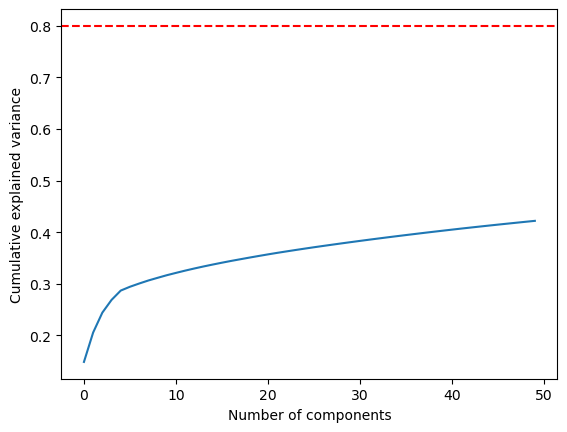

NameError: name 'pearsonr' is not defined

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import cross_val_score, KFold,  cross_val_predict
from sklearn.impute import SimpleImputer

feature_cols = [c for c in train_vars.columns if c not in ['participant_id', 'p_factor']]
X = train_vars[feature_cols].values
y = train_vars['p_factor'].values

# --- Quick look: how much variance do the first N components explain? ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(SimpleImputer(strategy='mean').fit_transform(X))
pca_full = PCA(n_components=50).fit(X_scaled)

import matplotlib.pyplot as plt
plt.plot(np.cumsum(pca_full.explained_variance_ratio_))
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.axhline(0.8, color='r', linestyle='--')
plt.show()

# --- Nested-CV-safe pipeline: impute -> scale -> PCA -> ridge ---
pipe = Pipeline([
    ('impute', SimpleImputer(strategy='mean')),
    ('scale', StandardScaler()),
    ('pca', PCA(n_components=20)),
    ('ridge', RidgeCV(alphas=np.logspace(-5, 5, 75)))
])

outer_cv = KFold(n_splits=5, shuffle=True, random_state=0)
scores = cross_val_score(pipe, X, y, cv=outer_cv, scoring='r2')
y_pred = cross_val_predict(pipe, X, y, cv=outer_cv)

# Overall correlation between true and predicted p_factor across all folds
r, p_value = pearsonr(y, y_pred)

print(f"R^2 per fold: {scores}")
print(f"Mean R^2: {scores.mean():.3f} ± {scores.std():.3f}")
print(f"Pearson r (CV predictions vs true): r={r:.3f}, p={p_value:.4g}")

In [14]:
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([
    ('impute', SimpleImputer(strategy='mean')),
    ('scale', StandardScaler()),
    ('pca', PCA()),
    ('ridge', RidgeCV(alphas=np.logspace(-5, 5, 75)))
])

param_grid = {'pca__n_components': [5, 10, 20, 30, 50, 70, 100]}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='r2')
grid.fit(X, y)
print("Best n_components:", grid.best_params_)
print("Best CV R^2:", grid.best_score_)

Best n_components: {'pca__n_components': 10}
Best CV R^2: 0.0542667736361591


In [16]:
print(grid)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('impute', SimpleImputer()),
                                       ('scale', StandardScaler()),
                                       ('pca', PCA()),
                                       ('ridge',
                                        RidgeCV(alphas=array([1.00000000e-05, 1.36500781e-05, 1.86324631e-05, 2.54334576e-05,
       3.47168682e-05, 4.73887961e-05, 6.46860766e-05, 8.82969996e-05,
       1.20526094e-04, 1.64519059e-04, 2.24569800e-04, 3.06539530e-04,
       4.18428851e-04, 5.71158648e-...
       3.69460121e+02, 5.04315949e+02, 6.88395207e+02, 9.39664831e+02,
       1.28264983e+03, 1.75082703e+03, 2.38989257e+03, 3.26222201e+03,
       4.45295851e+03, 6.07832313e+03, 8.29695852e+03, 1.13254132e+04,
       1.54592774e+04, 2.11020343e+04, 2.88044415e+04, 3.93182876e+04,
       5.36697695e+04, 7.32596543e+04, 1.00000000e+05])))]),
             param_grid={'pca__n_components': [5, 10, 20, 30, 50, 70, 100]},
            

In [18]:
# --- Fit final model on all training data ---
feature_cols = [c for c in train_vars.columns if c not in ['participant_id', 'p_factor']]

X_train = train_vars[feature_cols].values
y_train = train_vars['p_factor'].values

# same pipeline structure as before, refit on ALL training subjects
final_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='mean')),
    ('scale', StandardScaler()),
    ('pca', PCA(n_components=20)),   # or grid.best_params_['pca__n_components'] if you used GridSearchCV
    ('ridge', RidgeCV(alphas=np.logspace(-3, 3, 20)))
])
final_pipe.fit(X_train, y_train)

print(f"Chosen ridge alpha: {final_pipe.named_steps['ridge'].alpha_}")

# --- Predict on test data ---
X_test = test_vars[feature_cols].values
test_preds = final_pipe.predict(X_test)

# --- Save predictions ---
predictions_df = pd.DataFrame({
    'participant_id': test_vars['participant_id'].values,
    'p_factor': test_preds
})

predictions_df.to_csv('test_predictions.csv', index=False)
predictions_df

Chosen ridge alpha: 1000.0


,participant_id,p_factor
0,2285120424,-0.121342
1,1854364375,-0.422991
2,1448081953,-0.337743
3,1342685465,-0.162949
4,3289562482,-0.507230
...,...,...
316,4190603704,-0.198866
317,1910420386,-0.607944
318,3993637691,-0.282498
319,2726043986,-0.967602


To train and perform the linear regression analysis, we will use the
[`LinearRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)
type from scikit-learn.

In [ ]:
# Import the LinearRegression type:
from sklearn.linear_model import LinearRegression

# LinearRegression requires a matrix whose columns are the variables and whose
# final column is the value being predicted (the p_factor for us). We can
# extract these columns straight from the dataframes we generated.
train_matrix = train_vars.loc[:, ['ba1_surface_area', 'p_factor']].values
# We need to exclude rows with NaNs for training:
train_okrows = np.all(~np.isnan(train_matrix), axis=1)
train_matrix = train_matrix[train_okrows]

# Train the regression using the training matrix:
lreg = LinearRegression()
lreg.fit(train_matrix[:, :1], train_matrix[:, 1])

# Display the trained regression parameters:
print("Linear Regression:")
print("  Intercept:", lreg.intercept_)
print("  Slope:", lreg.coef_)

### Step 3. Predict the `p_factor` of the Test Data

In [ ]:
# We can apply the trained linear regression object `lreg` to the 1-column
# matrix of ba1_surface_area values in the test_vars dataframe.
test_matrix = test_vars.loc[:, ['ba1_surface_area']].values
test_okrows = np.all(~np.isnan(test_matrix), axis=1)

# Apply the model:
p_factor_predictions = np.zeros(len(test_matrix))
p_factor_predictions[test_okrows] = lreg.predict(test_matrix[test_okrows])

# Display the predictions:
p_factor_predictions

### Step 4. Save and Commit the Results

To save and commit the results, we first need to save the predicted `p_factor`
data into the test dataframe (where there are currently NaNs). In the cell
above, we calculated the variable `test_okrows` that indicates which rows
of the `test_vars`, `test_matrix`, and `test_data` objects were predicted
(those that weren't predicted were excluded due to missing surface area data
in our case).

We can use this to insert the predicted `p_factor` data into `test_data`.

In [ ]:
test_data.loc[:, 'p_factor'] = p_factor_predictions

# Display the resulting test data:
test_data

We now need to save the data to disk. We want to put this in the `results`
directory of the repository.

In [ ]:
# The sep='\t' option here is necessary for tab-separated-value (as opposed to
# comma-separated-value) files. The `index=False` just indicates that pandas
# doesn't need to write out its own index column.

group_name = 'example'  # Change this to be your group name!

test_data.to_csv(f'results/{group_name}.tsv', sep='\t', index=False)

Once the tsv file has been saved, you can commit it to your GitHub repository
then push it and submit a pull request to the `results` branch of the original
repository!